# Example 3.8

Estimated k1 = 0.01307
Estimated k2 = 0.00727


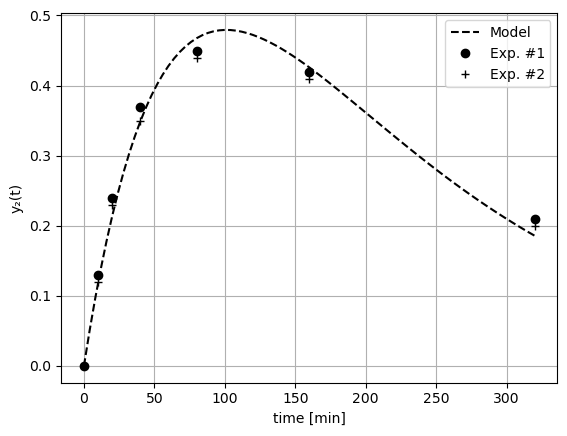

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

# -------------------------------------------------
# Macro to estimate kinetic constants
# -------------------------------------------------

# Experimental data
texp = np.array([10, 20, 40, 80, 160, 320])
yexp1 = np.array([0.13, 0.24, 0.37, 0.45, 0.42, 0.21])
yexp2 = np.array([0.12, 0.23, 0.35, 0.44, 0.41, 0.20])

# Initial conditions
Y0 = np.array([1.0, 0.0, 0.0])

# Initial guess for parameters
x0 = np.array([0.01, 0.005])

# -------------------------------------------------
# Function that defines the kinetic model
# -------------------------------------------------
def System(t, y, k1, k2):
    """
    Function that describes the kinetic model of the system
    """
    dy1 = -k1 * y[0]
    dy2 = k1 * y[0] - k2 * y[1]
    dy3 = k2 * y[1]
    return [dy1, dy2, dy3]

# -------------------------------------------------
# Objective function for parameter estimation
# -------------------------------------------------
def Integrate(x):
    """
    Function that computes the objective function for parameter fitting;
    in this case there are two experimental curves
    """
    k1, k2 = x

    # Time points including t = 0
    t_eval = np.concatenate(([0], texp))

    # Integrate the kinetic system
    sol = solve_ivp(
        System,
        (0, texp[-1]),
        Y0,
        t_eval=t_eval,
        args=(k1, k2),
        method='RK45'
    )

    # Model prediction for y2(t)
    y_model = sol.y[1]

    # Differences between model and experiments
    delta1 = y_model - np.concatenate(([Y0[1]], yexp1))
    delta2 = y_model - np.concatenate(([Y0[1]], yexp2))

    # Sum of squared errors
    return np.sum(delta1**2 + delta2**2)

# -------------------------------------------------
# Parameter optimization
# -------------------------------------------------
result = minimize(Integrate, x0, method='BFGS')
k1_opt, k2_opt = result.x

print(f'Estimated k1 = {k1_opt:.5f}')
print(f'Estimated k2 = {k2_opt:.5f}')

# -------------------------------------------------
# Final simulation using optimal parameters
# -------------------------------------------------
t_sim = np.arange(0, 321, 4)

solution = solve_ivp(
    System,
    (0, 320),
    Y0,
    t_eval=t_sim,
    args=(k1_opt, k2_opt),
    method='RK45'
)

# -------------------------------------------------
# Plot results
# -------------------------------------------------
plt.plot(solution.t, solution.y[1], 'k--', label='Model')
plt.plot([0, *texp], [0, *yexp1], 'ko', label='Exp. #1')
plt.plot([0, *texp], [0, *yexp2], '+k', label='Exp. #2')

plt.xlabel('time [min]')
plt.ylabel('y₂(t)')
plt.legend()
plt.grid(True)

# Save figure
filename = 'Figure_3_12.png'
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()
